/tmp/ipykernel_3146/707830106.py:12: RuntimeWarning: overflow encountered in exp
  return C0 * np.exp(-k * t)


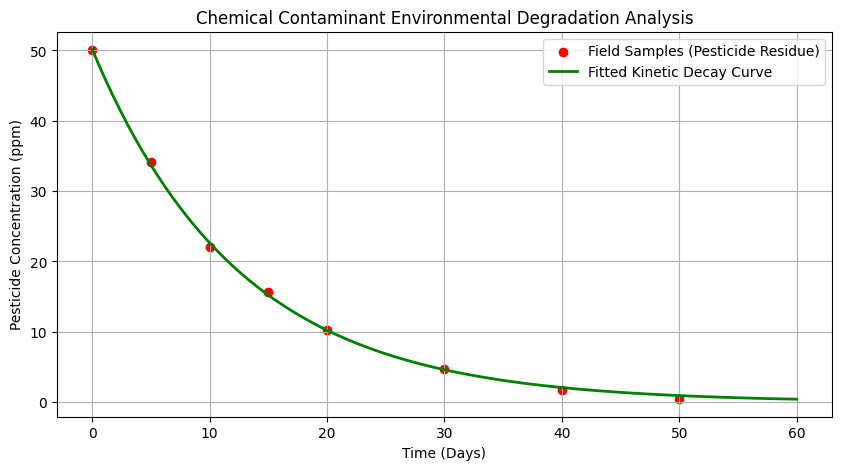


--- PROJECT 3 SUCCESSFUL ---
Estimated Initial Concentration (C0): 50.17 ppm
Degradation Rate Constant (k): 0.0795 day^-1
Calculated Chemical Half-life: 8.72 days


In [6]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# 1. Environmental tracking data (Days vs Concentration in ppm)
days = np.array([0, 5, 10, 15, 20, 30, 40, 50])
concentration = np.array([50.0, 34.2, 22.1, 15.6, 10.2, 4.7, 1.8, 0.5])

# 2. Define First-Order Kinetics Function: C(t) = C0 * exp(-k * t)
def degradation_model(t, C0, k):
    return C0 * np.exp(-k * t)

# 3. Fit the model to the data using non-linear least squares
params, covariance = curve_fit(degradation_model, days, concentration)
C0_est, k_est = params

# 4. Calculate Half-Life (t_1/2 = ln(2) / k)
half_life = np.log(2) / k_est

# 5. Plot the kinetic curve
time_axis = np.linspace(0, 60, 100)
plt.figure(figsize=(10, 5))
plt.scatter(days, concentration, color='red', label='Field Samples (Pesticide Residue)')
plt.plot(time_axis, degradation_model(time_axis, C0_est, k_est), label='Fitted Kinetic Decay Curve', color='green', linewidth=2)
plt.xlabel('Time (Days)')
plt.ylabel('Pesticide Concentration (ppm)')
plt.title('Chemical Contaminant Environmental Degradation Analysis')
plt.legend()
plt.grid(True)
plt.show()

print("\n--- PROJECT 3 SUCCESSFUL ---")
print(f"Estimated Initial Concentration (C0): {C0_est:.2f} ppm")
print(f"Degradation Rate Constant (k): {k_est:.4f} day^-1")
print(f"Calculated Chemical Half-life: {half_life:.2f} days")
